In [24]:
import tensorflow as tf

In [25]:
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_X, train_y), (test_X, test_y) = fashion_mnist.load_data()
train_X = train_X/255.0
test_X  = test_X/255.0
train_X = train_X.reshape(-1, 28, 28, 1)
test_X = test_X.reshape(-1, 28, 28, 1)

In [26]:
train_X.shape

(60000, 28, 28, 1)

In [27]:
model = tf.keras.Sequential(
	[
		# input layer
		tf.keras.layers.Input(shape=(28, 28, 1)),

		# hidden layer
		tf.keras.layers.Conv2D(kernel_size=(3, 3), filters=16),
		tf.keras.layers.MaxPool2D(pool_size=(2,2), strides=(2,2)),

		tf.keras.layers.Conv2D(kernel_size=(3, 3), filters=32),
		tf.keras.layers.MaxPool2D(pool_size=(2,2), strides=(2,2)),

		tf.keras.layers.Conv2D(kernel_size=(3, 3), filters=64),
		tf.keras.layers.MaxPool2D(pool_size=(2,2), strides=(2,2)),

		# hidden layer
		tf.keras.layers.Flatten(),

		tf.keras.layers.Dropout(rate=0.2),
		tf.keras.layers.Dense(units=128, activation="relu"),

		# output layer
		tf.keras.layers.Dropout(rate=0.2),
		tf.keras.layers.Dense(units=10, activation="softmax")
	]
)

In [28]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 3, 3, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,906 (128.54 KB)

 Trainable params: 32,906 (128.54 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.compile(
	loss = "sparse_categorical_crossentropy",
	optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001),
	metrics = ["accuracy"]
)

In [30]:
history = model.fit(
	train_X, train_y,
	epochs = 100,
	batch_size = 256,
	validation_split = 0.25
)

Epoch 1/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.6424 - loss: 0.9856 - val_accuracy: 0.7723 - val_loss: 0.6322
Epoch 2/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7730 - loss: 0.6262 - val_accuracy: 0.7972 - val_loss: 0.5542
Epoch 3/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7966 - loss: 0.5581 - val_accuracy: 0.8155 - val_loss: 0.5067
Epoch 4/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8146 - loss: 0.5134 - val_accuracy: 0.8275 - val_loss: 0.4735
Epoch 5/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8259 - loss: 0.4813 - val_accuracy: 0.8367 - val_loss: 0.4442
Epoch 6/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8346 - loss: 0.4576 - val_accuracy: 0.8456 - val_loss: 0.4228
Epoch 7/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8412 - loss: 0.4376 - val_accuracy: 0.8501 - val_loss: 0.4099
Epoch 8/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.8465 - loss: 0.4209 - val_ac

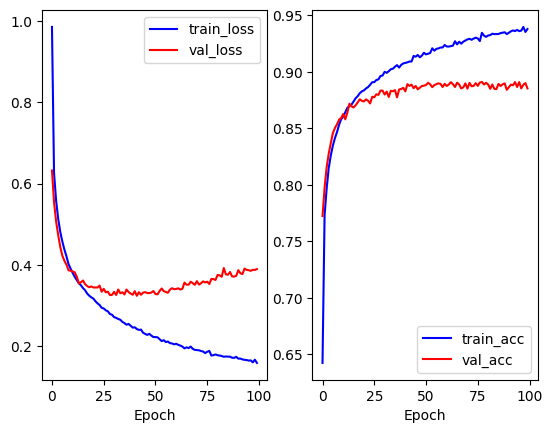

In [31]:
import matplotlib.pyplot as plt

plt.subplot(1,2,1) # loss

plt.plot(history.history["loss"], "b-", label="train_loss" ) # train - loss
plt.plot(history.history["val_loss"], "r-", label="val_loss" ) # val - loss
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1,2,2) # acc

plt.plot(history.history["accuracy"], "b-", label="train_acc" ) # train - acc
plt.plot(history.history["val_accuracy"], "r-", label="val_acc" ) # val - acc
plt.xlabel("Epoch")
plt.legend()